# Calculating Terrain Ruggedness at the Ethnologue Polygon Level (GMTED2010)

Inputs: GMTED2010 elevation tiles in `maps/raw/DEM2/` (exported from GEE at 100m — see [`gmted2010_elevation_download.ipynb`](gmted2010_elevation_download.ipynb)). Extends to 84°N, covering polar regions beyond SRTM.

Measures produced per Ethnologue polygon (v2 suffix to distinguish from SRTM-based measures):
- `elev_mean_v2`, `elev_std_v2` — mean and standard deviation of elevation.
- `tri_mean_v2` — polygon mean of the **Terrain Ruggedness Index** (Riley, DeGloria & Elliot 1999). Per pixel, TRI is the mean absolute elevation difference against the 8 neighbors. Same construction used in Nunn & Puga (2012).

> The zip archives next to the extracted .tif must be unzipped first — this notebook only globs `*.tif`.

In [2]:
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
# Set base project path
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")

# Set file paths
poscol_path = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"

gmted_path = base_path / "maps" / "raw" / "DEM2"

In [4]:
# Read the Ethnologue polygons
ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]

print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [5]:
# List all GMTED2010 raster tiles
raster_files = sorted(glob(str(gmted_path / "*.tif")))
print(f"Found {len(raster_files)} raster files")

src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

# Merge to ~1km resolution (matches the convention used in other measures)
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),          # ~1km in degrees
    resampling=Resampling.average,
)

elev = mosaic[0].astype(np.float32)
print("Mosaic shape:", elev.shape)

Found 36 raster files
Mosaic shape: (14000, 36000)


In [6]:
# Check CRS of each input raster, reproject ethnologue to match
for i, src in enumerate(src_files_to_mosaic[:3]):
    print(f"Raster {i} CRS:", src.crs)

ethnologue = ethnologue.to_crs(src_files_to_mosaic[0].crs)

Raster 0 CRS: EPSG:4326
Raster 1 CRS: EPSG:4326
Raster 2 CRS: EPSG:4326


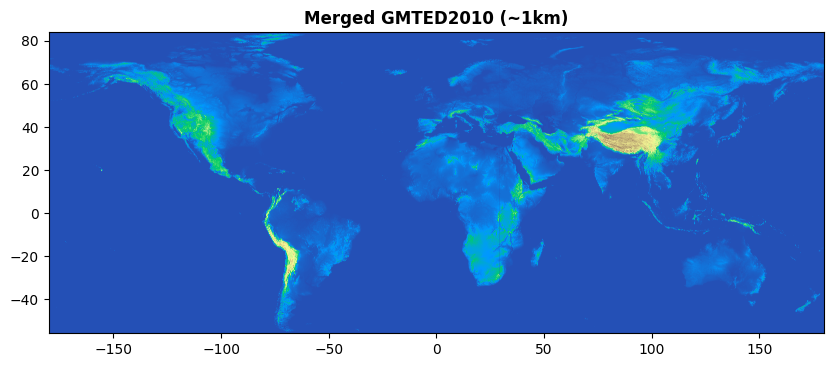

In [7]:
# Quick look at the merged DEM
fig, ax = plt.subplots(figsize=(10, 5))
show(mosaic, transform=out_trans, ax=ax, title="Merged GMTED2010 (~1km)", cmap="terrain")
plt.show()

In [8]:
# --- Per-pixel Terrain Ruggedness Index (Riley, DeGloria & Elliot 1999) ---
# TRI_i = mean over the 8 neighbors of |elev_i - elev_neighbor|.

# Treat very negative / sentinel values as NaN (elevation voids commonly -9999 or similar)
elev_nan = np.where(elev < -1000, np.nan, elev)

# Pad edges with NaN so np.roll doesn't wrap around the globe
padded = np.pad(elev_nan, pad_width=1, mode="constant", constant_values=np.nan)
center = padded[1:-1, 1:-1]

neighbor_offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

abs_diffs = np.empty((8, center.shape[0], center.shape[1]), dtype=np.float32)
for k, (dy, dx) in enumerate(neighbor_offsets):
    neighbor = padded[1+dy : 1+dy+center.shape[0], 1+dx : 1+dx+center.shape[1]]
    abs_diffs[k] = np.abs(center - neighbor)

tri = np.nanmean(abs_diffs, axis=0).astype(np.float32)
print("TRI stats — min:", np.nanmin(tri), "max:", np.nanmax(tri), "mean:", np.nanmean(tri))

TRI stats — min: 0.0 max: 2499.5 mean: 8.741753


In [9]:
# --- Zonal stats: elevation mean + std, and TRI mean ---

def zstats(array, stat_list, nodata=-9999.0):
    """Write array to an in-memory GeoTIFF and run zonal_stats."""
    arr = np.where(np.isnan(array), nodata, array).astype(np.float32)
    with MemoryFile() as memfile:
        with memfile.open(
            driver="GTiff",
            height=arr.shape[0],
            width=arr.shape[1],
            count=1,
            dtype="float32",
            transform=out_trans,
            crs="EPSG:4326",
            nodata=nodata,
        ) as dataset:
            dataset.write(arr, 1)
        return zonal_stats(ethnologue, memfile.name, stats=stat_list, geojson_out=True)

elev_stats = zstats(elev_nan, ["mean", "std"])
tri_stats  = zstats(tri,      ["mean"])

ethnologue["elev_mean_v2"] = [f["properties"]["mean"] for f in elev_stats]
ethnologue["elev_std_v2"]  = [f["properties"]["std"]  for f in elev_stats]
ethnologue["tri_mean_v2"]  = [f["properties"]["mean"] for f in tri_stats]

ethnologue[["ID", "elev_mean_v2", "elev_std_v2", "tri_mean_v2"]].head()

,ID,elev_mean_v2,elev_std_v2,tri_mean_v2
0,RUS-RUS,298.611065,341.270474,20.665456
1,ENG-USA,740.968604,711.581453,28.349150
2,POR-BRA,348.747449,270.845289,17.948668
3,ENG-AUS,259.374062,208.980760,12.141061
4,CMN-CHN,903.208146,872.450904,42.107639


In [10]:
df_ethnologue = ethnologue[["ID", "elev_mean_v2", "elev_std_v2", "tri_mean_v2"]]
print(len(df_ethnologue))
df_ethnologue.head()

7087


,ID,elev_mean_v2,elev_std_v2,tri_mean_v2
0,RUS-RUS,298.611065,341.270474,20.665456
1,ENG-USA,740.968604,711.581453,28.349150
2,POR-BRA,348.747449,270.845289,17.948668
3,ENG-AUS,259.374062,208.980760,12.141061
4,CMN-CHN,903.208146,872.450904,42.107639


In [11]:
# Export to CSV
df_ethnologue.to_csv(gmted_path / "ethnologue_ruggedness_v2.csv", index=False)
print("Exported ethnologue_ruggedness_v2.csv")

Exported ethnologue_ruggedness_v2.csv
